# **Performance comparison**

This notebook explain how to reproduce the Figure n.5 of the article to compare the performance of our proposed estimator ```Un-CP``` to litterature estimators

*Author: Benjamin Pineau, Barbara Pascal, Sébastien Bourguignon*

### **Important remark**:

This notebook requires a GitHub repository. Please install [EpiJointSpatiotempEstim](https://github.com/elasalle/EpiJointSpatiotempEstim/) before using this notebook. 

Write the path to this toolbox on your device below.

In [1]:
import sys 
from pathlib import Path

# path to the EpiJointSpatiotempEstim repository on your device
# ======================================================================================================== #
path_EpiJointSpatiotempEstim = "/Users/benji/Documents/Centrale_Nantes/EI3/OPDOC/EpiJointSpatiotempEstim/" #
# ======================================================================================================== #

prog_python_path = Path(path_EpiJointSpatiotempEstim).resolve()

if str(prog_python_path) not in sys.path:
    sys.path.insert(0, str(prog_python_path))

In [2]:
%run ../utils/preamble.py

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Set the seed of your choice, by default the one used to generate the article data.

In [3]:
np.random.seed(6300)

## **Creation of synthetic data**

To account for the large intrinsic variability of infection counts, we use a *scaled* Poisson model :

$$
\frac{\mathsf{Z}_t}{\gamma} \mid \mathsf{Z}_1, \, \dots, \,  \mathsf{Z}_{t-1}, \,\mathsf{R}_t \sim \mathcal{P}\left(\frac{ \Phi^{\mathsf{Z}}_t  \mathsf{R}_t}{\gamma} \right).
$$

where $\gamma = \omega \times \delta$, $\delta$ represents a reference scale and $\omega$ represents a variance level. We generate synthetic data for different variance levels to mimic various dynamic of infection counts. 

Here we create $L = 10$ independent training datasets $ \mathcal{S}_{\omega^{(\ell)}}, \, \ell=1,\dots, L$  at different variance levels $\omega^{(\ell)}, \, \ell=1, \dots, L$ logarithmically spaced between $0.01$ and $0.05$.

In [4]:
# define the variance levels
list_varlevel = np.logspace(np.log10(0.01), np.log10(0.05), 10)

dico_varlevel = {str(i + 1): round(list_varlevel[i],4) for i in range(len(list_varlevel))}

In [5]:
# Creation of training and test datasets

# train
N_replica_train = 5
dico_datasets_varlevel_train = create_synthetic_data('train', N_replica_train, dico_varlevel)

# test
N_replica_test = 200
dico_datasets_varlevel_test = create_synthetic_data('test', N_replica_test, dico_varlevel)

Extracting information from train.csv.
Creating dataset for variance level $\omega =$ 0.01
Creating dataset for variance level $\omega =$ 0.012
Creating dataset for variance level $\omega =$ 0.0143
Creating dataset for variance level $\omega =$ 0.0171
Creating dataset for variance level $\omega =$ 0.0204
Creating dataset for variance level $\omega =$ 0.0245
Creating dataset for variance level $\omega =$ 0.0292
Creating dataset for variance level $\omega =$ 0.035
Creating dataset for variance level $\omega =$ 0.0418
Creating dataset for variance level $\omega =$ 0.05


**Remark**: 

You can save the synthetic data created from ```create_synthetic_data```. To do so, please set ```save = True``` and ```save_path = 'path/to/folder'```such that: 

*create_synthetic_data('train', N_replica_train, dico_varlevel, save = True, save_path = 'path/to/folder')*.

The folders will be organised as follow:

```text
dataset
├── varlevel1
│    ├── groundTruthR1_realization1
│    ├── groundTruthR1_realization2
│    ├── ...
│    ├── groundTruthR2_realization1
│    ├── ...
│    
├── varlevel2 
│    ├── groundTruthR1_realization1
│    ├── ...
│
└── ...

## **Training of the model**

### **Training for different variance level datasets** $\mathcal{S}_{\omega^{(\ell)}}$

Here we focus on the training of the proposed $\mathsf{UnCP}$ model on the $L$ indenpendant datasets at different variance levels $\omega^{(\ell)}$

### Unrolled Chambolle–Pock Layer

One layer of the unrolled Chambolle–Pock algorithm applied to the estimation of the COVID-19 reproduction number can be written as:

$$
\left\{
\begin{aligned}
\boldsymbol{\mathsf{U}}^{[k+1]} &=
\mathrm{prox}_{\sigma (\lambda\lVert \cdot \rVert_1)^*} \left( \boldsymbol{\mathsf{U}^{[k]}} + \sigma \mathsf{H}_k \overline{\boldsymbol{\mathsf{R}}}^{[k]} \right), \\[0.4em]
\boldsymbol{\mathsf{R}}^{[k+1]} &=
\mathrm{prox}_{\rho \mathsf{D}_{\mathrm{KL}}\left(\boldsymbol{\mathsf{Z}} \mid \boldsymbol{\cdot} \odot \Phi^{\boldsymbol{\mathsf{Z}}}\right)}
\left(
\boldsymbol{\mathsf{R}}^{[k]} -
\rho \mathsf{H}_k^\top \boldsymbol{\mathsf{U}}^{[k+1]}
\right), \\[0.4em]
\overline{\boldsymbol{\mathsf{R}}}^{[k+1]} &= 2\boldsymbol{\mathsf{R}}^{[k+1]} - \boldsymbol{\mathsf{R}}^{[k]} .
\end{aligned}
\right.
$$

---

### Learnable Parameters

We learn a linear operator $\mathsf{H}_k$ by imposing a filter structure on it :
$$    
    \mathsf{h}^{[k]} =
    \begin{bmatrix}
    c_{1}^{[k]}  & \cdots & c_{25}^{[k]} & 0 &\cdots & 0 \\
    0 & c_{1}^{[k]} & \cdots & c_{25}^{[k]} & 0 &\cdots  \\
    \vdots & \vdots & \vdots & \ddots & \ddots & \vdots \\
    \end{bmatrix} \in \mathbb{R}^{(T - 25)\times T}
    , \quad k \in {1, \dots, k_{\text{layer}}}.
$$
Furthemore we apply $n$ filters in parallel for the same layer, which is equivalent to consider the filter $\mathsf{H}_k \in \mathbb{R}^{n(T - 25)\times T}$ such that for $x \in \mathbb{R}^T$ :
$$
    \mathsf{H}_k(x) = \big[\mathsf{h}_i^{[k]}*x\big]_{i = 1}^{n}
, \quad \text{with} \quad
    \mathsf{h}^{[k]}_i = 
    \begin{bmatrix}
    c_{1, i}^{[k]}  & \cdots & c_{25, i}^{[k]} \\
    \end{bmatrix}
    , \; i \in {1, \dots, n}
$$

---

### Config settings

It is possible to set up the following settings: 
- **`device`**: device on which to perform the calculation, basically CPU or CUDA
- **`dataset`**: training dataset path
- **`nepoch`**: number of epoches
- **`K_layer`**: number of layers
- **`nb_filter`**: number of filters per layer
- **`learning_rate`** = learning rate
- **`R_init_type`**: input $\mathsf{R}^{[0]}$ of the network. Choice between $\mathsf{R}^{[0]} = \mathsf{R}^{[\mathrm{MLE}]}$ and $\mathsf{R}^{[0]} = \boldsymbol{1}$
- **`nbatch`**: batch size

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

dico_model_mono_varlevel = {}
config_mono_varlevel = {}
loss_mono_varlevel = {}

for i, (param_name, param_varlevel) in enumerate(dico_varlevel.items()):

    print(f'Traing the UnCP model for variance level n.{param_name}.')
    
    config_mono_varlevel[param_name] = TrainConfig(
        device = device,
        nepoch = 10000,
        K_layer = 10,
        nbatch = 60,
        learning_rate = 1e-4,
        nb_filter = 20,
        #dataset = dico_datasets_omega_train[param_name],
        dataset = f'../data/datasets/test/varlevel{param_name}',
        R_init_type = 'ones',
        save = False,
        save_path = '../'
    )

    dico_model_mono_varlevel[param_name], loss_mono_varlevel[param_name] = gradient_descent_database(config_mono_varlevel[param_name])

Traing the UnCP model for variance level n.1.
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec
exec

Training:   0%|          | 1/10000 [00:02<5:55:27,  2.13s/it]

Loss :  0.7819


Training:   0%|          | 1/10000 [00:04<11:26:29,  4.12s/it]


KeyboardInterrupt: 

**Remark**: 

You can save the final model and the training loss from ```gradient_descent_database```. To do so, please set ```save = True``` and ```save_path = 'path/to/folder'``` in the ```TrainConfig```class.

### **Training for a multi-variance level dataset** $\mathcal{S}_{\Omega}$

Here we focus on the training of the proposed  $\mathsf{UnCP}$ model on a multiple variance level dataset $\mathcal{S}_{\Omega} = \bigcup_{\ell = 1}^L \mathcal{S}_{\omega^{(\ell)}}$

In [6]:
dico_dataset = create_multiple_variance_level_dataset(dico_datasets_varlevel_train, save = True, save_path = '../train')

In [ ]:
model_multi_varlevel = {}
config_multi_varlevel = {}
loss_multi_varlevel = {}

print(f'Traing the UnCP model for multiple variance levels dataset.')
    
config_multi_varlevel = TrainConfig(
    device = device,
    nepoch = 10,
    K_layer = 10,
    nbatch = 60,
    learning_rate = 1e-4,
    nb_filter = 20,
    dataset = dico_dataset,
    R_init_type = 'ones',
)

model_multi_varlevel, loss_multi_varlevel = gradient_descent_database(config_multi_varlevel)

Traing the UnCP model for multiple omega dataset.


Training:  20%|██        | 2/10 [00:00<00:00, 10.50it/s]

Loss :  0.7013
Loss :  0.6978
Loss :  0.6943


Training:  60%|██████    | 6/10 [00:00<00:00, 13.88it/s]

Loss :  0.6908
Loss :  0.6873
Loss :  0.6837
Loss :  0.68


Training: 100%|██████████| 10/10 [00:00<00:00, 10.84it/s]

Loss :  0.6763
Loss :  0.6725
Loss :  0.6687


## **Display data**

You can load the models used for the paper or use the previous model learned in this notebook. To do so, set ```load_trained_model``` consequently.

In [12]:
load_trained_model = False

if load_trained_model:

    model_multi_varlevel = nn_conv('cpu', 10, learning_rate=1e-4, nb_filter=20)
    load_model(model_multi_varlevel, '../data/models/varlevelAll_K10_J20.pth')
    
    dico_model_mono_varlevel = {}
    for i, (param_name, param_varlevel) in enumerate(dico_varlevel.items()):
        dico_model_mono_varlevel[param_name] = nn_conv('cpu', 10, learning_rate=1e-4, nb_filter=20)
        load_model(dico_model_mono_varlevel[param_name], f'../data/models/varlevel{param_name}_K10_J20.pth')

Compute the SNR for each data of the test dataset for the $\mathsf{MLE}$, $\mathsf{EpiEstim}$, $\mathcal{S}_{\omega^{(\ell)}}-\mathsf{UnCP}$ and $\mathcal{S}_{\Omega}-\mathsf{UnCP}$ estimators. 

In [13]:
dico_SNR_UnCP_mono = {}
dico_SNR_UnCP_multi = {}
dico_SNR_EpiEstim = {}
dico_SNR_MLE = {}
config_mono_varlevel = {}

for i, (param_name, param_varlevel) in enumerate(dico_varlevel.items()):
    
    config_mono_varlevel[param_name] = TrainConfig(
        device = device,
        nepoch = 10,
        K_layer = 10,
        nb_filter = 20,
        dataset = f'../data/datasets/test/varlevel{param_name}',

        #dataset = dico_datasets_omega_test[param_name],

        R_init_type = 'ones',
    )
    # MLE estimator
    dico_SNR_MLE[param_name] = perf_SNR(config_mono_varlevel[param_name], 'MLE')

    # EpiEstim estimator
    dico_SNR_EpiEstim[param_name] = perf_SNR(config_mono_varlevel[param_name], 'EpiEstim')

    # mono-variance level UnCP estimator
    dico_SNR_UnCP_mono[param_name] = perf_SNR(config_mono_varlevel[param_name], dico_model_mono_varlevel[param_name])

    # multi-variance level UnCP estimator
    dico_SNR_UnCP_multi[param_name] = perf_SNR(config_mono_varlevel[param_name], model_multi_varlevel)

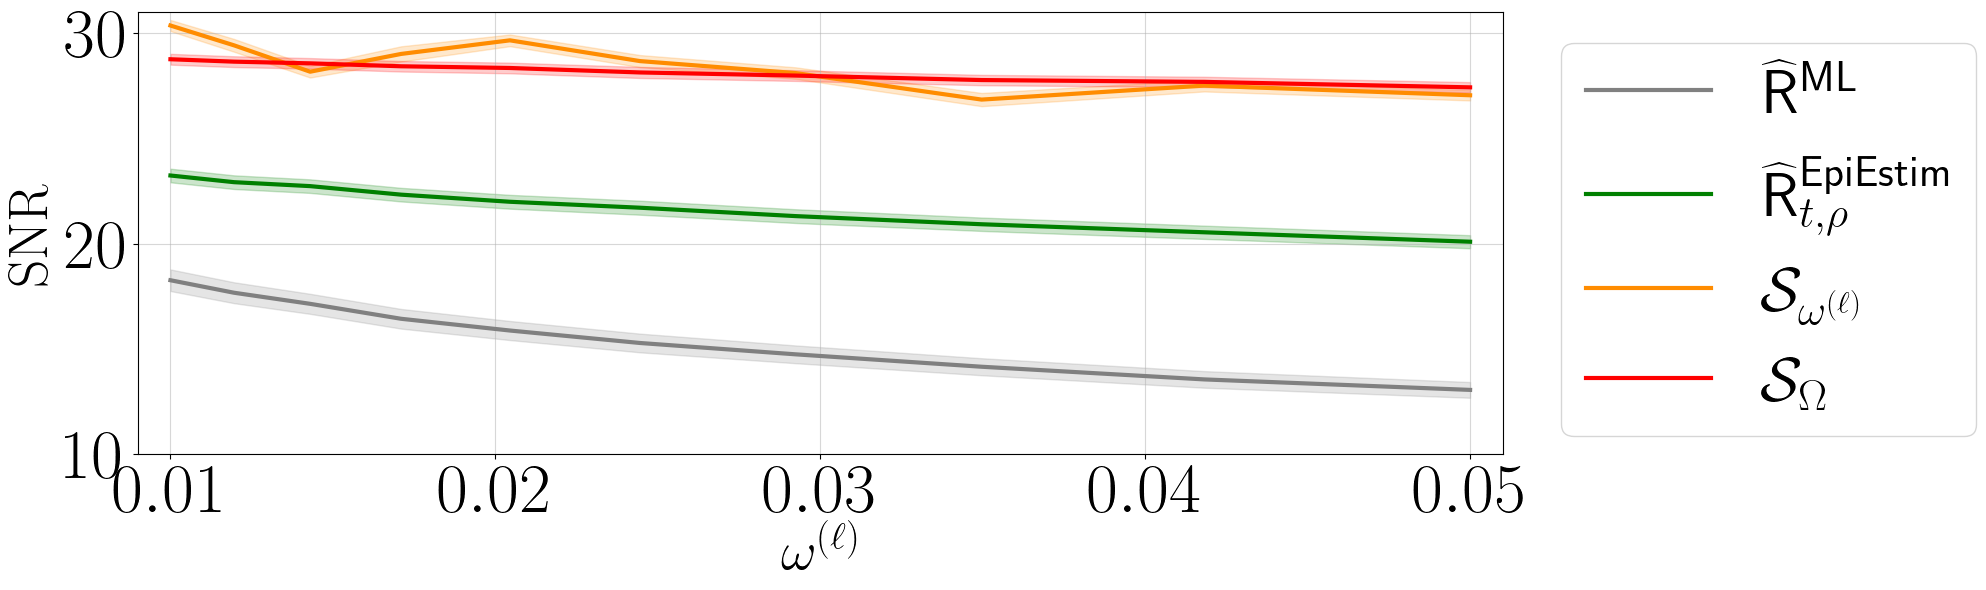

In [14]:
fig, ax = plt.subplots(figsize=(20,6))

# =======================
# MLE estimator info
means = []
stds = []
for i, (param_name, dico_param) in enumerate(dico_SNR_MLE.items()):
    means.append(dico_param["mean"])
    stds.append(dico_param["gaussian_width"])

means = np.array(means)
stds = np.array(stds)
plt.plot(list_varlevel, means, label=r'$\widehat{\mathsf{R}}^{\mathsf{ML}}$', linewidth=3, color = 'grey')
plt.fill_between(list_varlevel, means - stds, means + stds, alpha = 0.2, color = 'grey')
# =======================


# =======================
# EpiEstim estimator info
means = []
stds = []
for i, (param_name, dico_param) in enumerate(dico_SNR_EpiEstim.items()):
    means.append(dico_param["mean"])
    stds.append(dico_param["gaussian_width"])

means = np.array(means)
stds = np.array(stds)
plt.plot(list_varlevel, means, label=r'$\widehat{\mathsf{R}}_{t,\rho}^{\mathrm{\tiny\mathsf{EpiEstim}}}$', linewidth=3, color = color_green_cori)
plt.fill_between(list_varlevel, means - stds, means + stds, alpha = 0.2, color = color_green_cori)
# =======================


# =======================
# mono-UnCP estimator info
means = []
stds = []
for i, (param_name, dico_param) in enumerate(dico_SNR_UnCP_mono.items()):
    means.append(dico_param["mean"])
    stds.append(dico_param["gaussian_width"])

means = np.array(means)
stds = np.array(stds)
plt.plot(list_varlevel, means, label = r'$\mathcal{S}_{\omega^{(\ell)}}$', linewidth=3, color = color_orange)
plt.fill_between(list_varlevel, means - stds, means + stds, alpha = 0.2, color = color_orange)
# =======================


# =======================
# multi-UnCP estimator info
means = []
stds = []
for i, (param_name, dico_param) in enumerate(dico_SNR_UnCP_multi.items()):
    means.append(dico_param["mean"])
    stds.append(dico_param["gaussian_width"])

means = np.array(means)
stds = np.array(stds)
plt.plot(list_varlevel, means, label = r'$\mathcal{S}_{\Omega}$', linewidth=3, color = 'red')
plt.fill_between(list_varlevel, means - stds, means + stds, alpha = 0.2, color = 'red')
# =======================


ax.set_ylim(10, 31)
ax.set_xlim(0.009, 0.051)
ax.set_ylabel("SNR", fontsize=40)
ax.set_xlabel(r"$\omega^{(\ell)}$", fontsize=40)
ax.grid(True, linestyle="-", alpha=0.5)


ax.legend(fontsize = 35)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize = 45, 
)

plt.tight_layout()
plt.show()